In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("All imports successful")

All imports successful


X shape (1000, 2)
y shape (1000,)
Class distribution: [505 495]


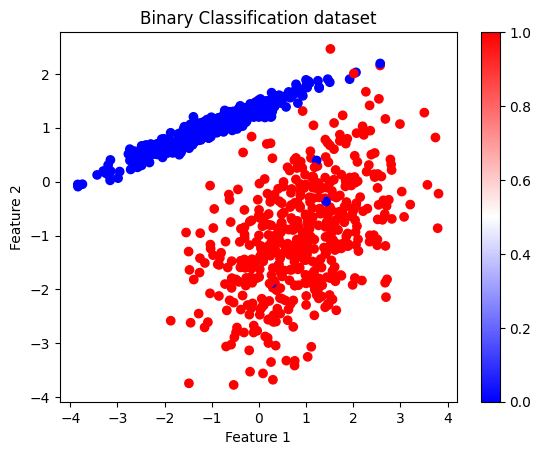

In [49]:
#Generate a binary classification dataset form make_classification module of sklearn

X,y=make_classification(
    n_samples=1000, #1000 data points
    n_features=2,   #only 2 features for visualizatoin and understanding
    n_redundant=0, #no redundant features
    n_informative=2, #both features contains information which affects y
    random_state=14, #to generate consistent result
    n_clusters_per_class=1 #each class will have only one centroid
)
print("X shape",X.shape) #(1000,2)
print("y shape",y.shape) #(1000,)
print("Class distribution:", np.bincount(y)) #should be equal approx 500-500

plt.scatter(X[:,0],X[:,1],c=y, cmap='bwr')
plt.colorbar()
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification dataset")
plt.show()


In [50]:
#Train Test Split
#80% Training and 20% Test
# Train only of Train data, keep the test data separate
# It tells how much model generalise to unseen data and prevents overfitting

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=14
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training Set size:",X_train.shape)
print("Test Set Size:",X_test.shape)

Training Set size: (800, 2)
Test Set Size: (200, 2)


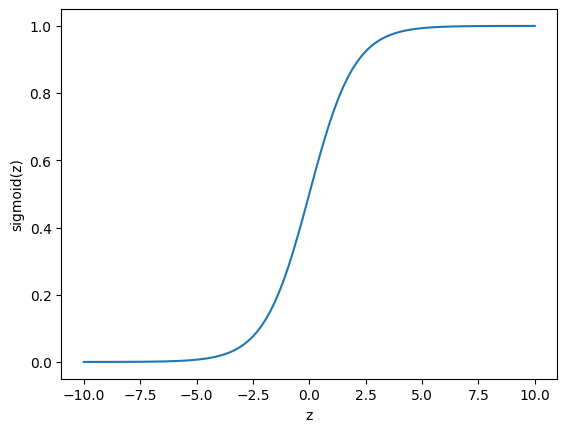

In [51]:
# Sigmoid fiunction
# It maps any number in range 0 to 1,
# g(z)=sigmoid(z)
# sigmoid(z)=1/(1+e^(-z))

def sigmoid(z):
    return 1/(1+np.exp(-z))

z=np.linspace(-10,10,100)
plt.plot(z,sigmoid(z))
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.show()
# It will generate a s shape curve
# print(sigmoid(-10),sigmoid(0),sigmoid(10))

In [54]:
# Predict y_hat
# First find the probability of the sample belonging to the class 1 using sigmoid function
# prob=sigmoid(wx+b)
# now if prob >0.1 , prediction is 1, otherwise 0 (this is what we generally use in some cases we might change the threshold

def pred_prob(X,w,b):
    return sigmoid(np.dot(X,w)+b) #Returns probability of class 1 for each sample
    
def predict(X,w,b):
    y_hat=(pred_prob(X,w,b)>0.5).astype(int) #Return predicted value for each sample
    return y_hat

# Cost function for logistic regression is 
# m is number of samples
# J= -1/m(from i=1 to m summation(y*log(probability_y)+(1-y)*(log(1-probability_y))
def compute_cost(X,y,w,b):
    m=len(y)
    proba=pred_prob(X,w,b)
    proba=np.clip(proba,1e-7,1-1e-7)
    cost=-1/m*(np.sum(y*np.log(proba)+(1-y)*(np.log(1-proba))))
    return cost

# Computing Gradients
# dj_dw is derivative of J with respect to w, and dj_db is derivative of J with respect to b, J is the cost
# This calculating gradients is similar to compute gradients function in linear regression except here instead of y_hat we use probability of y_hat

def compute_gradients(X,y,w,b):
    m=len(y)
    y_hat_prob=pred_prob(X,w,b)
    error=y_hat_prob-y
    dj_dw=(1/m)*(np.dot(X.T,error))
    dj_db=(1/m)*np.sum(error)
    return dj_dw,dj_db
    

In [55]:
# test
w = np.zeros(X_train.shape[1])
b = 0.0

initial_cost = compute_cost(X_train, y_train, w, b)
print("Initial cost:", initial_cost)

Initial cost: 0.6931471805599452


In [56]:
# Gradient descent
# going down the slope to find local minima
def gradient_descent(X,y,w,b,iterations,alpha):
    J_history=[]
    for i in range(iterations):
        dj_dw,dj_db=compute_gradients(X,y,w,b)
        w=w-alpha*dj_dw
        b=b-alpha*dj_db
        if i%100:
            J_history.append(compute_cost(X,y,w,b))
    return w,b,J_history
            

In [57]:
# Train the model
alpha =0.01
iterations=10000
w_final,b_final,J_history=gradient_descent(X_train,y_train,w,b,iterations,alpha)
print("Learned weight:",w_final)
print("Learned Biases:",b_final)
print("Final_cost:", J_history[-1])


Learned weight: [ 2.630116   -3.27387487]
Learned Biases: 0.3816585599118066
Final_cost: 0.07816146335417991


In [58]:
# Evaluate on test set

y_pred=predict(X_test,w_final,b_final)
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy on test set:",accuracy*100,"%\n")

# Precision = tp/(tp+fp)
# Recall = tp/(tp+fn)
# F1- score = 2*precision*recall/(precision+recall)
# Macro avg precision = (precision_class_0+precision_class_1)/2 similarly for recall and f1 score
# Weighted avg precision = (precision_class_0*number_of_class_0_in_test_set+precision_class_1*number_of_Class_1_in_test)/total_test_size
# Similarly for recall,f1


print("Confusion Matrix\n")
print(confusion_matrix(y_test,y_pred),"\n")
print(classification_report(y_test,y_pred))

Accuracy on test set: 97.5 %

Confusion Matrix

[[ 86   1]
 [  4 109]] 

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        87
           1       0.99      0.96      0.98       113

    accuracy                           0.97       200
   macro avg       0.97      0.98      0.97       200
weighted avg       0.98      0.97      0.98       200



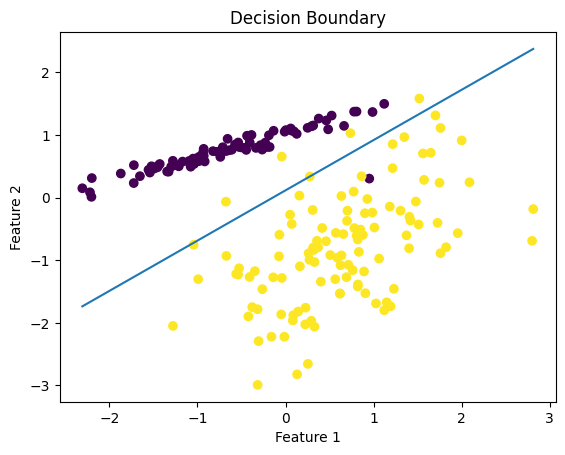

In [59]:
# Plot data
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test)

# Create x values (just along x-axis)
x1 = np.linspace(X_test[:, 0].min(), X_test[:, 0].max(), 100)

# Compute corresponding y values (decision boundary)
#decision boundary is where w1x1+w2x2+b=0 , here we have x1 in upper line now we have to find x2 in terms of x1
# w2x2=-(w1x1+b)
# x2=-(w1x1+b)/w2

x2 = -(w_final[0]*x1 + b_final) / w_final[1]

# Plot the line
plt.plot(x1, x2)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Boundary")
plt.show()

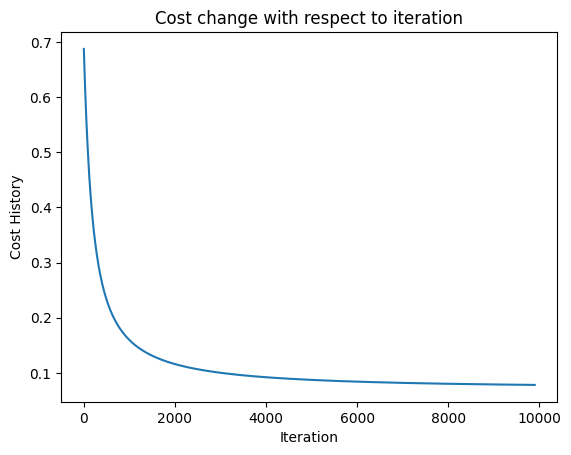

In [60]:
# We can see the cost decreases as iteration increases,
# We can also notice that after some iterations the cost does not decreas significantly as the model has already converged

plt.plot(J_history)
plt.xlabel("Iteration")
plt.ylabel("Cost History")
plt.title("Cost change with respect to iteration")
plt.show()


In [61]:
# Comparison with sklearn
# from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegression

sklearn_model=LogisticRegression(random_state=14)
sklearn_model.fit(X_train,y_train)
sklearn_accuracy=sklearn_model.score(X_test,y_test)

print("Our implementation Accuracy:",accuracy*100,"%")
print("SKleanr Accuracy:",sklearn_accuracy*100,"%")

Our implementation Accuracy: 97.5 %
SKleanr Accuracy: 97.5 %


In [62]:
print("=" * 50)
print("        LOGISTIC REGRESSION FROM SCRATCH")
print("=" * 50)
print(f"\nDataset: 1000 samples, 2 features, binary classes")
print(f"Train/Test split: 80/20")
print(f"\nModel learned:")
print(f"  Weights: {w_final}")
print(f"  Bias:    {b_final:.4f}")
print(f"\nTraining:")
print(f"  Learning rate: {alpha}")
print(f"  Iterations:    {iterations}")
print(f"  Initial cost:  {J_history[0]:.4f}")
print(f"  Final cost:    {J_history[-1]:.4f}")
print(f"\nResults:")
print(f"  Test Accuracy:  {accuracy:.2%}")
print(f"  Sklearn Check:  {sklearn_accuracy:.2%}")
print("=" * 50)

        LOGISTIC REGRESSION FROM SCRATCH

Dataset: 1000 samples, 2 features, binary classes
Train/Test split: 80/20

Model learned:
  Weights: [ 2.630116   -3.27387487]
  Bias:    0.3817

Training:
  Learning rate: 0.01
  Iterations:    10000
  Initial cost:  0.6876
  Final cost:    0.0782

Results:
  Test Accuracy:  97.50%
  Sklearn Check:  97.50%
